In [44]:
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [45]:
# fetch dataset 
statlog_shuttle = fetch_ucirepo(id=148) 
  
# data (as pandas dataframes) 
X = statlog_shuttle.data.features 
y = statlog_shuttle.data.targets # variável alvo

In [46]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

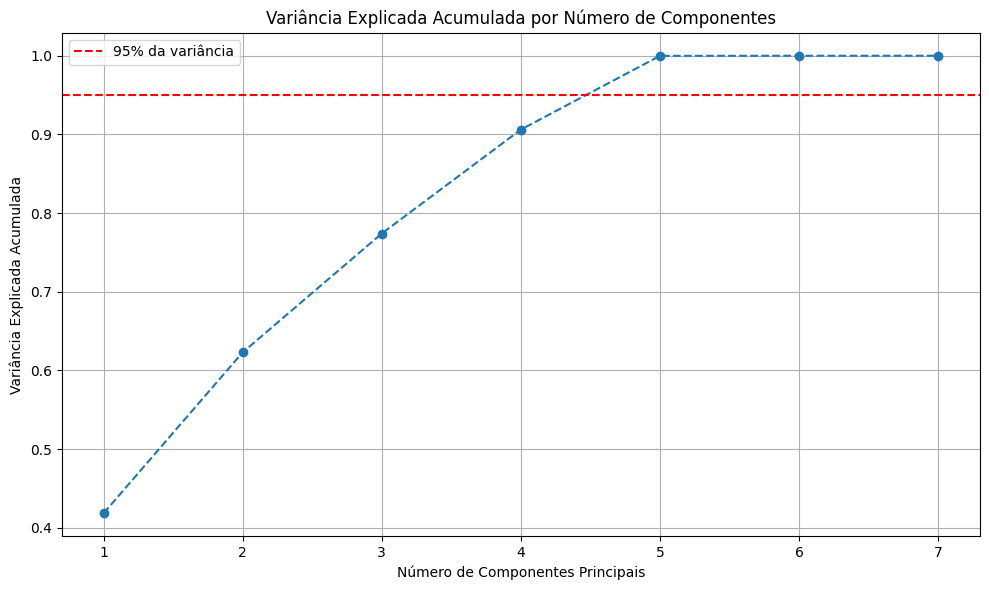

Número de componentes principais mantidos: 5


In [47]:
pca_full = PCA()
pca_full.fit(X_scaled)

# Plotando a variância explicada acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         pca_full.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('Variância Explicada Acumulada por Número de Componentes')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Explicada Acumulada')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% da variância')
plt.legend()
plt.tight_layout()
plt.show()

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Número de componentes principais mantidos: {pca.n_components_}")

In [ ]:
# 4. Dividir treino e teste
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier


X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y)

# 5. Preparar parâmetros para GridSearch (validação cruzada)
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance']
}

knn = KNeighborsClassifier()

# 6. GridSearchCV com 5 folds para encontrar melhores parâmetros
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1, return_train_score=True)
grid_search.fit(X_train, y_train.values.ravel())

print("Melhores parâmetros encontrados:", grid_search.best_params_)
print("Melhor acurácia média na validação cruzada:", grid_search.best_score_)

# 7. Extraindo resultados para plotar as métricas no grid
results = pd.DataFrame(grid_search.cv_results_)

Melhores parâmetros encontrados: {'metric': 'euclidean', 'n_neighbors': 6, 'weights': 'uniform'}
Melhor acurácia média na validação cruzada: 0.9977370689655173


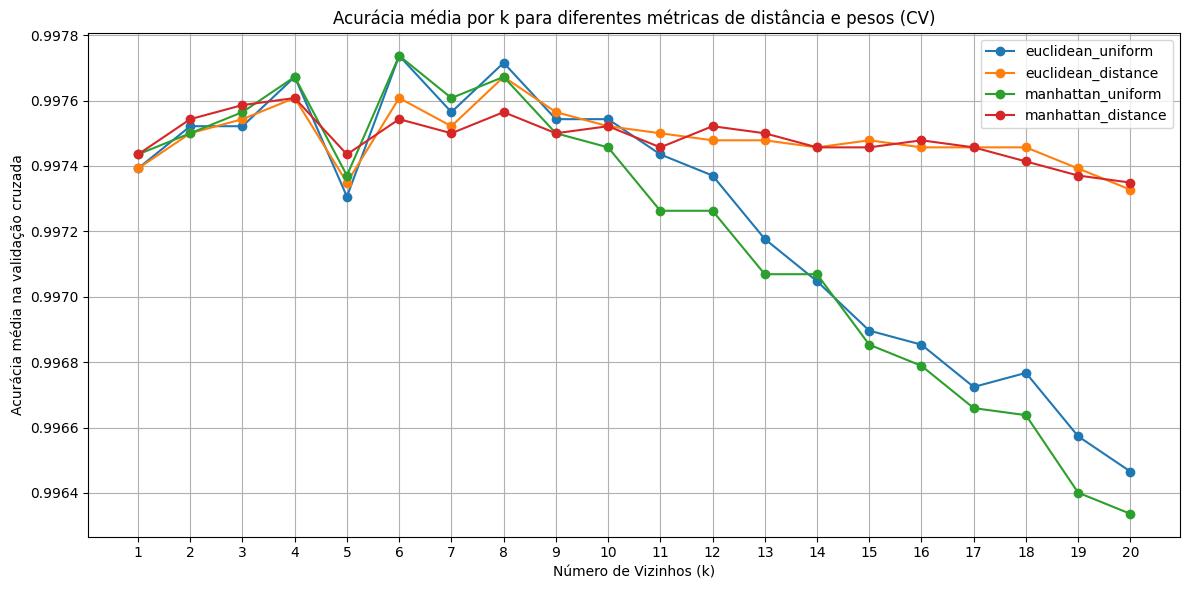

In [ ]:
# Vamos organizar os resultados para facilitar os gráficos
# Para cada combinação de metric e weights, plotar acurácia média em função de k

k_values = list(range(1, 21))
distances = ['euclidean', 'manhattan']
weights = ['uniform', 'distance']

plt.figure(figsize=(12, 6))

for dist in distances:
    for weight in weights:
        subset = results[
            (results['param_metric'] == dist) & 
            (results['param_weights'] == weight)
        ]
        # Ordenar por n_neighbors para garantir que o gráfico esteja correto
        subset = subset.sort_values('param_n_neighbors')
        plt.plot(k_values, subset['mean_test_score'], marker='o', label=f'{dist}_{weight}')

plt.title('Acurácia média por k para diferentes métricas de distância e pesos (CV)')
plt.xlabel('Número de Vizinhos (k)')
plt.ylabel('Acurácia média na validação cruzada')
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

In [58]:
for dist in distances:
    for weight in weights:
        subset = results[
            (results['param_metric'] == dist) &
            (results['param_weights'] == weight)
        ]
        # Encontrar índice do maior score
        best_idx = subset['mean_test_score'].idxmax()
        best_k = subset.loc[best_idx, 'param_n_neighbors']
        best_acc = subset.loc[best_idx, 'mean_test_score']
        print(f'Melhor k para {dist}_{weight}: {best_k} com acurácia {best_acc:.4f}')

Melhor k para euclidean_uniform: 6 com acurácia 0.9977
Melhor k para euclidean_distance: 8 com acurácia 0.9977
Melhor k para manhattan_uniform: 6 com acurácia 0.9977
Melhor k para manhattan_distance: 4 com acurácia 0.9976


In [59]:
# 8. Treinar modelo final com os melhores parâmetros usando todo o conjunto de treino
from sklearn.metrics import accuracy_score, precision_score, recall_score

knn_final = grid_search.best_estimator_
knn_final.fit(X_train, y_train.values.ravel())

# 9. Avaliar no conjunto de teste
y_pred_knn = knn_final.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred_knn, average='weighted', zero_division=0)

print("\nAvaliação final no conjunto de teste:")
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")


Avaliação final no conjunto de teste:
Acurácia: 0.9982
Precisão: 0.9977
Recall: 0.9982


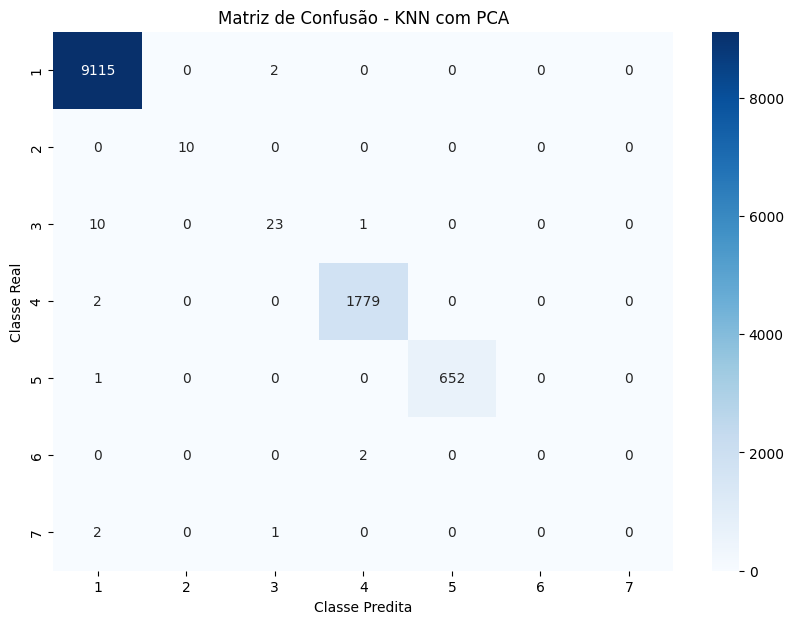

In [60]:
# 10. Matriz de confusão com seaborn
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.title("Matriz de Confusão - KNN com PCA")
plt.show()